# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `Pillow (PIL)` library. Complete both tasks and save your output images for comparison.


In [1]:
# Import the library
from PIL import Image
import numpy as np

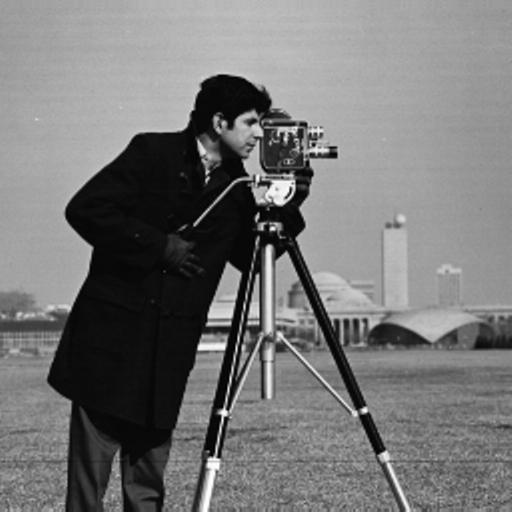

In [2]:
# ── Load image ────────────────────────────────────
from PIL import Image
from IPython.display import display

img = Image.open("cameraman.jpg")
display(img)

### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [3]:
# Get the size of the image
width, height = img.size
print("Original size:", width, height)

# scaling factors
scale_x = 2
scale_y = 2

Original size: 512 512


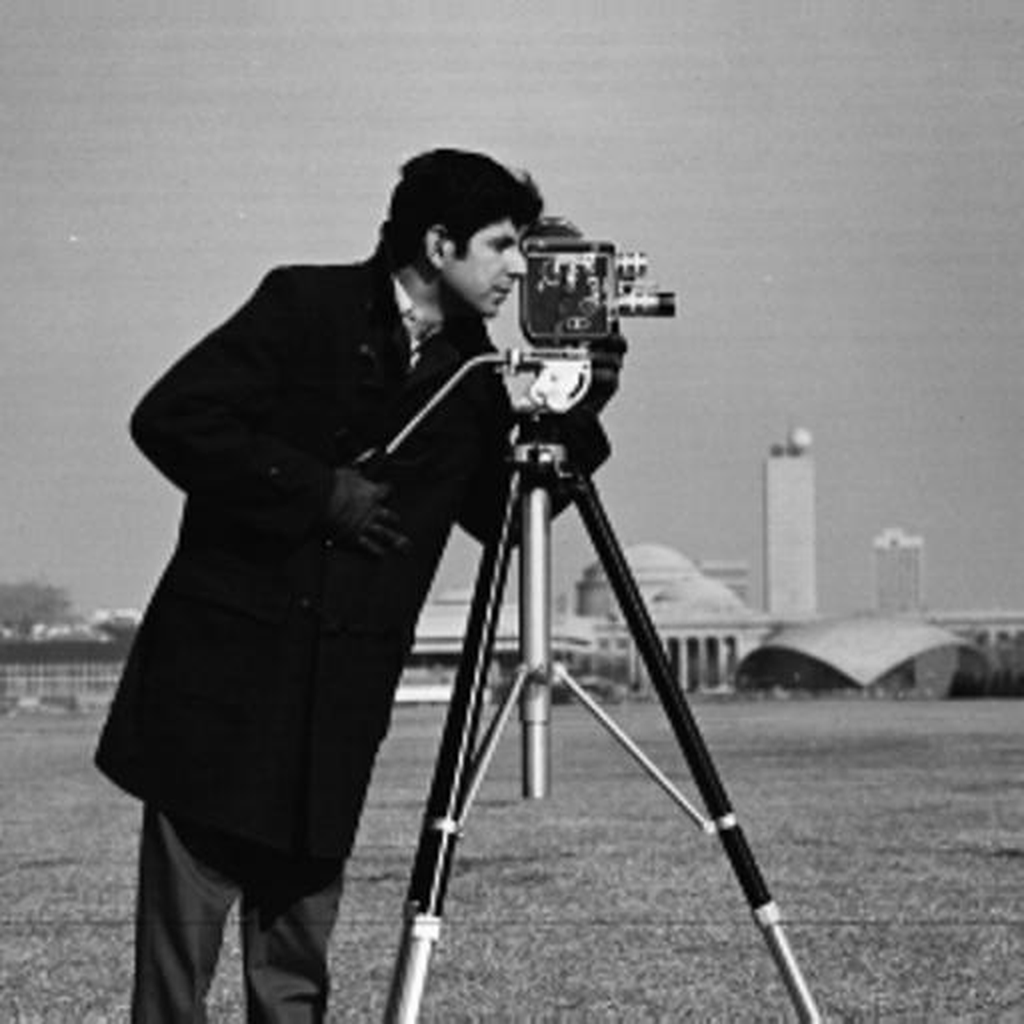

In [4]:
# ── 1. Increase size (scale ×2) ────────────────────

# Resize the image using PIL's built-in method
new_size = (int(width * scale_x), int(height * scale_y))
scaled_img = img.resize(new_size, Image.LANCZOS)
display(scaled_img)

In [5]:

# Save the scaled image and print the sizes (The new image name should be "task1_1_scaled.jpg")
scaled_img.save("task1_scaled.jpg")
print("New size:", scaled_img.size)

New size: (1024, 1024)


 non-uniform scale (cx=2, cy=1) → stretch horizontally only

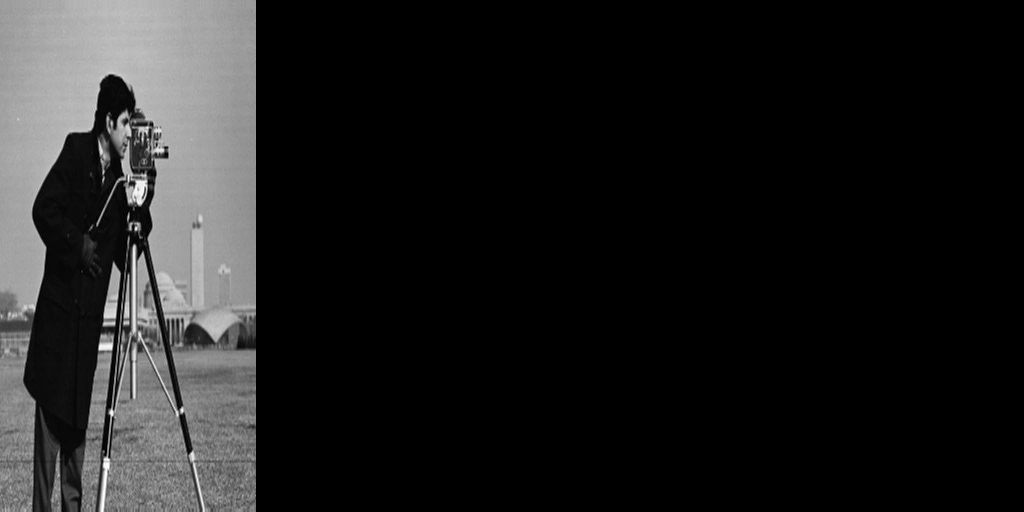

In [6]:
width, height = img.size

f = img.transform(
    (int(width*2), height),
    Image.AFFINE,
    (2, 0, 0,
     0, 1, 0)
)

display(f)

In [7]:
f.save("task1_nonuniform_scaled.jpg")
print("New size:", f.size)

New size: (1024, 512)


### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

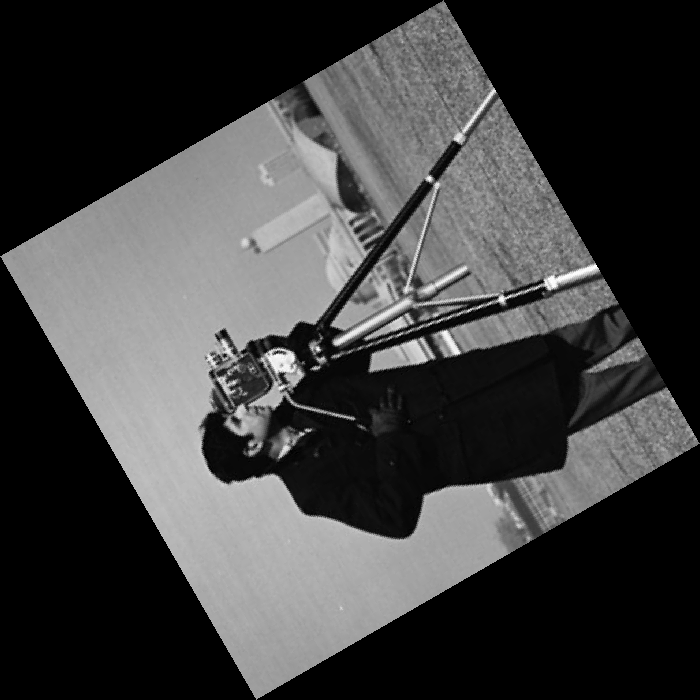

New size: (700, 700)


In [8]:
# ── 2. Rotate 120 degrees ──────────────────────────
rotated_img = img.rotate(120, expand=True)
display(rotated_img)
# Save the scaled image and print the sizes (The new image name should be "task1_2_rotated.jpg")
rotated_img.save("task1_2_rotated.jpg")
print("New size:", rotated_img.size)

### 3. Shear

In [9]:
# -- c. Get the image dimensions ────────────────────
width, height = img.size
print(width, height)

512 512


In [10]:
# -- d. define the shear matrix ──────────────────────────
# Choose X-axis or Y-axis shear. The shear factor controls how much the image slants — start with 0.5 then experiment.
shx = 0.5
shy = 0

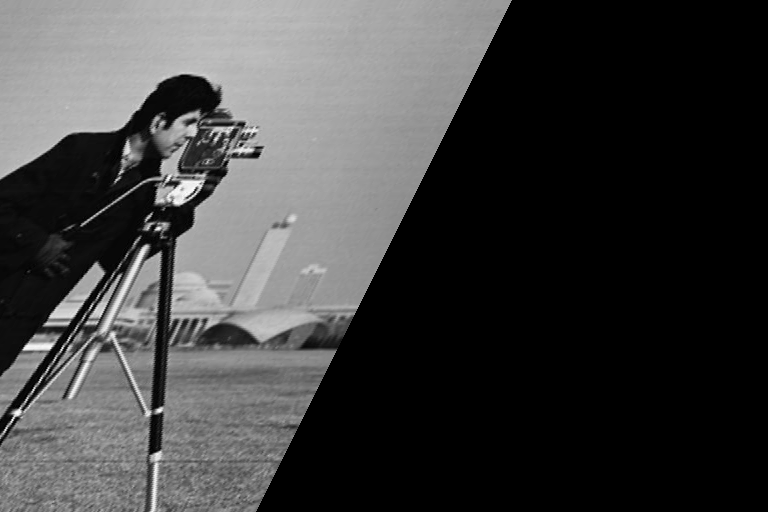

In [12]:
# -- e. Apply the shear transformation to the image ──────────────────────────
# PIL's transform() takes the inverse affine matrix:
# [ 1    shx   tx ]
# [ shy  1     ty ]
sheared_img = img.transform(
    (int(width + shx * height), height),   # حجم جديد
    Image.AFFINE,
    (1, shx, 0,
     0, 1, 0)
)
display(sheared_img)

In [13]:
# -- f. Save the sheared image(The new image name should be "task1_3_sheared.jpg")
sheared_img.save("task1_3_sheared.jpg")
print("New size:", sheared_img.size)

New size: (768, 512)


### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

# Intensity Transformations
Negative · Log · Power Law (Gamma)

In [ ]:

# ── 1. Negative ────────────────────────────────────
# Method 1: NumPy array manipulation
arr = np.array(img)
negative_arr = 255 - arr
negative_img = Image.fromarray(negative_arr)
display(negative_img)
negative_img.save("task2_1_negative_numpy.jpg")

In [ ]:
# Method 2: PIL's ImageOps
from PIL import ImageOps
negative_img2 = ImageOps.invert(img)
display(negative_img2)
negative_img2.save("task2_1_negative_pil.jpg")

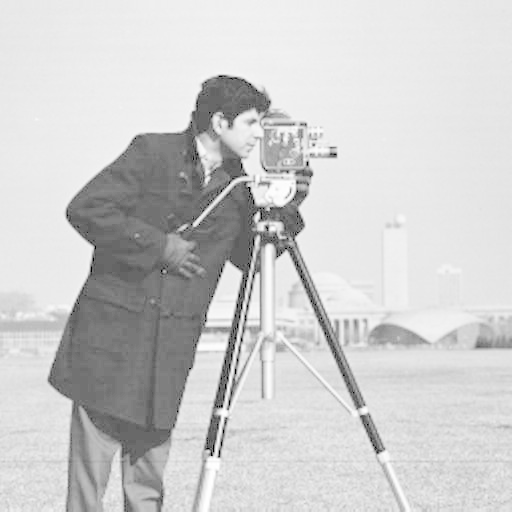

In [14]:
# ── 2. Log transformation ──────────────────────────
arr = np.array(img).astype(np.float32)
# s = c * log(1 + r)
c = 255 / np.log(1 + 255)
# Apply log transformation
log_transformed_arr = c * np.log(1 + arr)
# Clip values to [0,255] then convert to uint8
log_transformed_arr = np.clip(log_transformed_arr, 0, 255)
log_transformed_img = Image.fromarray(log_transformed_arr.astype(np.uint8))
display(log_transformed_img)
log_transformed_img.save("task2_2_log.jpg")

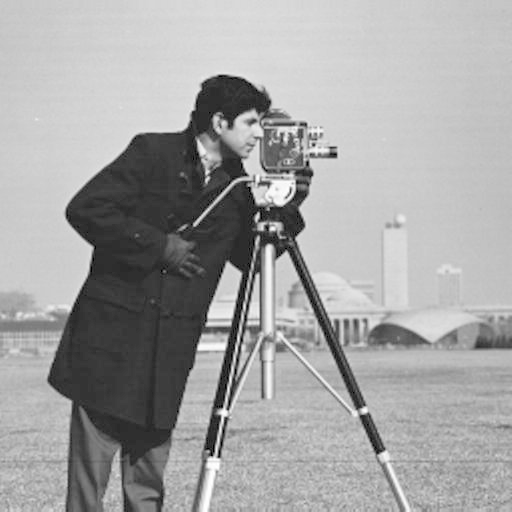

In [15]:

# ── 3. Power-law / Gamma correction ───────────────
arr = np.array(img).astype(np.float32)
gamma = 0.5
c = 255 / (255 ** gamma)
gamma_arr = c * (arr ** gamma)
gamma_arr = np.clip(gamma_arr, 0, 255)
gamma_img = Image.fromarray(gamma_arr.astype(np.uint8))
display(gamma_img)
gamma_img.save("task2_3_gamma.jpg")